# Exploratory Data Analysis（探索的データ分析）

## 目的
求人充足率低下の要因分析に向けて、求人・応募データの分布、欠損、年次差を確認する。
本Notebookでは、SQLで作成した分析マートをPythonに読み込み、データの品質や分布を確認したうえで、2025年と2026年の傾向を比較する。
この段階では仮説の統計的な有意性を判断するのではなく、合成データが分析可能な状態になっているか、また想定した方向性がデータに表れているかを探索的に確認する。

## 主な確認項目
- 60日以内募集枠充足率
- 給与ギャップ
- スキルギャップ
- 選考リードタイム
- 就業決定率

## 使用する分析マート
- `mart_job_analysis`
  - 1行 = 1求人
  - 求人属性、応募ファネル、就業決定数、60日以内募集枠充足率などを保持

- `mart_application_analysis`
  - 1行 = 1応募案件
  - 給与ギャップ、スキルギャップ、選考リードタイム、辞退・就業決定などを保持

## 1. ライブラリの読み込み
分析に必要なPythonライブラリを読み込む。

- `sqlite3`：SQLiteデータベースへ接続する
- `pandas`：表形式データをDataFrameとして扱う
- `numpy`：数値計算を行う
- `matplotlib`：グラフを作成する

In [262]:
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. SQLiteデータベースへの接続
Pythonから、合成データおよびSQL分析マートを格納したSQLiteデータベースへ接続する。

Notebookは `notebooks/` フォルダに保存しているため、1階層上の `database/` フォルダを参照する。

In [263]:
conn = sqlite3.connect(
    "../database/recruitment_analytics.sqlite"
)

### 接続先データベースの確認
想定したSQLiteファイルへ接続できていることを確認する。

In [264]:
pd.read_sql_query(
    "PRAGMA database_list;",
    conn
)

,seq,name,file
0,0,main,c:\Users\tomoe\OneDrive\PERSOL\キャリアスカウト\recrui...


## 3. 分析マートの読み込み
SQLで作成した2つの分析マートを、pandasのDataFrameとしてPythonへ読み込む。

- `job_df`：求人単位の分析データ
- `application_df`：応募案件単位の分析データ

SQLでデータの結合・集計を行い、Pythonではその結果を使って探索的データ分析を行う。

In [265]:
job_df = pd.read_sql_query(
    """
    SELECT *
    FROM mart_job_analysis
    """,
    conn
)

application_df = pd.read_sql_query(
    """
    SELECT *
    FROM mart_application_analysis
    """,
    conn
)

## 4. データ件数と内容の確認
読み込んだDataFrameについて、行数・列数と先頭データを確認する。

ここでは、SQLiteから想定したデータを正常に読み込めていることを確認する。

In [266]:
print("job_df:", job_df.shape)
print("application_df:", application_df.shape)

job_df: (20, 36)
application_df: (18, 62)


### 求人マートの先頭行

In [267]:
job_df.head()

,job_id,client_id,ra_id,open_date,close_date,job_status,open_year,open_month,occupation_id,occupation_name,...,confirmed_count,visit_count,completed_visit_count,cancelled_visit_count,placement_count,placement_60d_count,fill_rate_60d,avg_intent_to_recommend_days,avg_recommend_to_schedule_days,avg_intent_to_decision_days
0,JOB00001,CLI067,RA002,2025-08-28,2025-12-19,closed,2025,2025-08,OCC003,コールセンター,...,0,0,0,0,0,0,0.0,NaN,NaN,NaN
1,JOB00002,CLI074,RA009,2025-06-20,NaN,open,2025,2025-06,OCC003,コールセンター,...,0,0,0,0,0,0,0.0,4.0,NaN,NaN
2,JOB00003,CLI096,RA008,2025-07-05,2025-12-18,closed,2025,2025-07,OCC002,データ入力,...,0,0,0,0,0,0,0.0,0.0,NaN,NaN
3,JOB00004,CLI098,RA013,2025-05-21,2025-09-05,closed,2025,2025-05,OCC006,DM（データマネジメント）,...,0,0,0,0,0,0,0.0,NaN,NaN,NaN
4,JOB00005,CLI022,RA006,2025-09-28,NaN,open,2025,2025-09,OCC005,品質管理（QC）,...,0,0,0,0,0,0,0.0,NaN,NaN,NaN


### 応募案件マートの先頭行

In [268]:
application_df.head()

,application_id,job_id,candidate_id,ca_id,application_source,source_entry_id,source_introduction_id,intent_confirmed_date,recommendation_date,recommendation_result,...,visit_continue_flag,recommend_to_schedule_days,schedule_to_visit_days,placed_flag,decision_date,start_date,agreed_hourly_wage,intent_to_decision_days,open_to_decision_days,placed_within_60d_flag
0,APP00001,JOB00010,CAN00002,CA012,self_entry,ENT00008,NaN,2025-05-12,2025-05-12,accepted,...,1,1.0,3.0,1,2025-05-20,2025-06-16,2250.0,8.0,31.0,1
1,APP00002,JOB00003,CAN00003,CA017,ca_introduction,NaN,INT00006,2025-07-09,2025-07-09,rejected,...,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0
2,APP00003,JOB00002,CAN00003,CA017,self_entry,ENT00012,NaN,2025-07-11,NaN,NaN,...,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0
3,APP00004,JOB00009,CAN00003,CA017,self_entry,ENT00016,NaN,2025-07-19,NaN,NaN,...,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0
4,APP00005,JOB00009,CAN00004,CA011,ca_introduction,NaN,INT00007,2025-08-02,NaN,NaN,...,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0


## 5. データ型の確認
各列のデータ型と非欠損件数を確認する。
数値として分析したい列が数値型になっているか、想定外の欠損が大量に発生していないかを確認する。

### 求人マート

In [269]:
job_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   job_id                          20 non-null     str    
 1   client_id                       20 non-null     str    
 2   ra_id                           20 non-null     str    
 3   open_date                       20 non-null     str    
 4   close_date                      10 non-null     str    
 5   job_status                      20 non-null     str    
 6   open_year                       20 non-null     str    
 7   open_month                      20 non-null     str    
 8   occupation_id                   20 non-null     str    
 9   occupation_name                 20 non-null     str    
 10  occupation_group                20 non-null     str    
 11  location_id                     20 non-null     str    
 12  prefecture_name                 20 non-null     s

### 応募案件マート

In [270]:
application_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 62 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   application_id                   18 non-null     str    
 1   job_id                           18 non-null     str    
 2   candidate_id                     18 non-null     str    
 3   ca_id                            18 non-null     str    
 4   application_source               18 non-null     str    
 5   source_entry_id                  13 non-null     str    
 6   source_introduction_id           5 non-null      str    
 7   intent_confirmed_date            18 non-null     str    
 8   recommendation_date              8 non-null      str    
 9   recommendation_result            8 non-null      str    
 10  withdrawal_date                  4 non-null      str    
 11  withdrawal_reason                4 non-null      str    
 12  application_status               18

## 6. 欠損値の確認
列ごとの欠損値件数を確認する。
欠損が存在すること自体を異常とは判断しない。

例えば、推薦に進んでいない応募案件では `recommendation_date`、辞退していない案件では `withdrawal_date`、就業決定していない案件では `decision_date` がNULLになることは業務上自然である。

ここでは、想定していない列に欠損が発生していないかを確認する。

### 求人マート

In [271]:
job_df.isna().sum()

job_id                             0
client_id                          0
ra_id                              0
open_date                          0
close_date                        10
job_status                         0
open_year                          0
open_month                         0
occupation_id                      0
occupation_name                    0
occupation_group                   0
location_id                        0
prefecture_name                    0
area_group                         0
required_slots                     0
offered_hourly_wage                0
required_skill_level               0
work_style                         0
job_60d_observed_flag              0
entry_count                        0
converted_entry_count              0
application_count                  0
recommendation_count               0
recommendation_accepted_count      0
withdrawal_count                   0
screened_out_count                 0
confirmed_count                    0
v

### 応募案件マート

In [272]:
application_df.isna().sum()

application_id              0
job_id                      0
candidate_id                0
ca_id                       0
application_source          0
                           ..
start_date                 16
agreed_hourly_wage         16
intent_to_decision_days    16
open_to_decision_days      16
placed_within_60d_flag      0
Length: 62, dtype: int64

### 分析上重要な欠損・観察期間の確認
今回追加した分析項目について、欠損や観察期間の状態を確認する。

特に以下を確認する。

- `fill_rate_60d` のNULLは、60日間観察できていない求人と対応しているか
- `skill_gap` のNULLは、同職種経験がない応募案件と対応しているか
- 30日間観察できていない応募案件がどの程度存在するか

これらのNULLは必ずしもデータ不良ではなく、分析上意味のある欠損として扱う。

In [273]:
print("【求人：60日観察可能フラグ】")
display(
    job_df[
        [
            "job_60d_observed_flag",
            "fill_rate_60d",
        ]
    ]
    .groupby("job_60d_observed_flag", dropna=False)
    .agg(
        job_count=("fill_rate_60d", "size"),
        fill_rate_non_null_count=("fill_rate_60d", "count"),
    )
)

print("\n【応募：同職種経験とskill_gap】")
display(
    application_df[
        [
            "same_occupation_experience_flag",
            "skill_gap",
        ]
    ]
    .groupby("same_occupation_experience_flag", dropna=False)
    .agg(
        application_count=("skill_gap", "size"),
        skill_gap_non_null_count=("skill_gap", "count"),
    )
)

print("\n【応募：30日観察可能フラグ】")
display(
    application_df[
        "application_30d_observed_flag"
    ]
    .value_counts(dropna=False)
    .sort_index()
)

【求人：60日観察可能フラグ】


,job_count,fill_rate_non_null_count
job_60d_observed_flag,,
0,3,0
1,17,17



【応募：同職種経験とskill_gap】


,application_count,skill_gap_non_null_count
same_occupation_experience_flag,,
0,7,0
1,11,11



【応募：30日観察可能フラグ】


application_30d_observed_flag
0     1
1    17
Name: count, dtype: int64

## 7. 数値項目の基本統計量
主要な数値項目について、件数・平均・標準偏差・最小値・四分位数・最大値を確認する。

極端な値や業務上不自然な値が含まれていないかを確認する。

### 求人マートの主要数値項目

In [274]:
job_df[
    [
        "required_slots",
        "offered_hourly_wage",
        "required_skill_level",
        "entry_count",
        "application_count",
        "placement_count",
        "placement_60d_count",
        "job_60d_observed_flag",
        "fill_rate_60d",
    ]
].describe()

,required_slots,offered_hourly_wage,required_skill_level,entry_count,application_count,placement_count,placement_60d_count,job_60d_observed_flag,fill_rate_60d
count,20.000000,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000,17.000000
mean,1.650000,1945.000000,2.600000,1.35000,0.900000,0.100000,0.100000,0.850000,0.039176
std,0.875094,547.698534,1.187656,0.74516,0.852242,0.307794,0.307794,0.366348,0.110591
min,1.000000,1250.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1450.000000,1.750000,1.00000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,1.000000,1975.000000,3.000000,1.00000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,2.250000,2250.000000,3.000000,2.00000,1.000000,0.000000,0.000000,1.000000,0.000000
max,3.000000,3050.000000,5.000000,3.00000,3.000000,1.000000,1.000000,1.000000,0.333000


### 応募案件マートの主要数値項目

In [275]:
application_df[
    [
        "wage_gap",
        "wage_gap_rate",
        "wage_shortfall_rate",
        "same_occupation_experience_flag",
        "skill_gap",
        "intent_to_recommend_days",
        "recommend_to_schedule_days",
        "schedule_to_visit_days",
        "intent_to_decision_days",
        "screened_out_flag",
        "confirmed_flag",
        "withdrawal_flag",
        "placed_flag",
        "application_30d_observed_flag",
    ]
].describe()

,wage_gap,wage_gap_rate,wage_shortfall_rate,same_occupation_experience_flag,skill_gap,intent_to_recommend_days,recommend_to_schedule_days,schedule_to_visit_days,intent_to_decision_days,screened_out_flag,confirmed_flag,withdrawal_flag,placed_flag,application_30d_observed_flag
count,18.000000,18.000000,18.000000,18.000000,11.000000,8.000000,3.000000,3.000000,2.000000,18.000000,18.0,18.000000,18.000000,18.000000
mean,52.777778,0.057833,0.053889,0.611111,0.181818,2.875000,3.333333,5.333333,11.500000,0.333333,0.0,0.222222,0.111111,0.944444
std,420.948586,0.254183,0.088895,0.501631,0.750757,2.232071,2.081666,2.081666,4.949747,0.485071,0.0,0.427793,0.323381,0.235702
min,-850.000000,-0.370000,0.000000,0.000000,-1.000000,0.000000,1.000000,3.000000,8.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,-150.000000,-0.082250,0.000000,0.000000,0.000000,1.500000,2.500000,4.500000,9.750000,0.000000,0.0,0.000000,0.000000,1.000000
50%,-50.000000,-0.022000,0.022000,1.000000,0.000000,3.000000,4.000000,6.000000,11.500000,0.000000,0.0,0.000000,0.000000,1.000000
75%,125.000000,0.075000,0.082250,1.000000,0.000000,4.250000,4.500000,6.500000,13.250000,1.000000,0.0,0.000000,0.000000,1.000000
max,1150.000000,0.657000,0.370000,1.000000,2.000000,6.000000,5.000000,7.000000,15.000000,1.000000,0.0,1.000000,1.000000,1.000000


## 8. カテゴリ項目の分布確認
職種、勤務形態、応募経路、応募案件ステータスなどについて、カテゴリ別件数を確認する。

特定カテゴリへデータが極端に偏っていないか、想定外のカテゴリ値が存在しないかを確認する。

### 職種別求人件数

In [276]:
job_df["occupation_name"].value_counts()

occupation_name
DM（データマネジメント）    5
コールセンター          4
一般事務             3
データ入力            2
品質管理（QC）         2
薬事               2
CRA              1
CRC              1
Name: count, dtype: int64

### 勤務形態別求人件数

In [277]:
job_df["work_style"].value_counts()

work_style
onsite    11
hybrid     9
Name: count, dtype: int64

### 応募経路別件数

In [278]:
application_df["application_source"].value_counts()

application_source
self_entry         13
ca_introduction     5
Name: count, dtype: int64

### 応募案件ステータス別件数

In [279]:
application_df["application_status"].value_counts()

application_status
screened_out    6
rejected        4
withdrawn       4
placed          2
recommended     2
Name: count, dtype: int64

### 応募経路別・ステータス別件数

`self_entry` と `ca_introduction` で、選考結果の分布に違いがあるかを確認する。

特に、CA紹介では事前スクリーニングを行っているため、自己応募と比較して `screened_out` や後続選考への進み方がどのように異なるかを確認する。

In [280]:
pd.crosstab(
    application_df["application_source"],
    application_df["application_status"],
    margins=True,
)

application_status,placed,recommended,rejected,screened_out,withdrawn,All
application_source,,,,,,
ca_introduction,1,0,2,2,0,5
self_entry,1,2,2,4,4,13
All,2,2,4,6,4,18


## 9. 2025年・2026年の年次比較
求人公開年および応募年ごとに主要指標を集計し、2025年と2026年の方向性を確認する。

小規模テストデータのため、この段階では統計的な有意差を判断しない。

目的は、合成データ生成時に設定した仮説の方向性が分析データにも表れているかを探索的に確認することである。

### 求人単位の年次集計
求人件数、募集枠数、エントリー数、応募数、60日以内就業決定数を年別に集計する。

60日以内募集枠充足率は、データ期間末までに60日間の観察が可能な求人のみを対象として、
`60日以内就業決定数 ÷ 募集枠数`
で算出する。

観察期間が60日に満たない求人を分母へ含めると、まだ結果が確定していない求人を未充足として扱うことになるため除外する。

※データ期間末までに60日間の観察が可能な求人の定義
⇒ 求人公開日 + 60日 <= データ終了日（2026-09-30）
⇒ job_60d_observed_flag = 1

※applicationは、job_entriesもしくはca_introductionの内、応募意思確認まで進み、選考案件として管理対象になったものを管理する

In [281]:
# 60日間の観察が可能な求人だけを抽出
job_60d_observed_df = job_df[
    job_df["job_60d_observed_flag"] == 1
].copy()


# 年次全体の求人活動量
job_year_volume = (
    job_df
    .groupby("open_year")
    .agg(
        job_count=("job_id", "count"),
        total_slots=("required_slots", "sum"),
        total_entries=("entry_count", "sum"),
        total_applications=("application_count", "sum"),
    )
)


# 60日観察可能求人に限定した充足関連指標
job_year_60d = (
    job_60d_observed_df
    .groupby("open_year")
    .agg(
        observed_job_count=("job_id", "count"),
        observed_slots=("required_slots", "sum"),
        placements_60d=("placement_60d_count", "sum"),
    )
)


# 年次集計を結合
job_year_summary = (
    job_year_volume
    .join(job_year_60d, how="left")
)


# 60日以内募集枠充足率
job_year_summary["fill_rate_60d"] = (
    job_year_summary["placements_60d"]
    / job_year_summary["observed_slots"]
)


job_year_summary

,job_count,total_slots,total_entries,total_applications,observed_job_count,observed_slots,placements_60d,fill_rate_60d
open_year,,,,,,,,
2025,10,17,11,9,10,17,1,0.058824
2026,10,16,16,9,7,11,1,0.090909


### 応募案件単位の年次集計
応募件数、給与ミスマッチ、スキルミスマッチ、推薦までの日数、辞退率、就業決定率を年別に確認する。

給与ミスマッチについては、提示時給が希望時給を下回る割合を表す `wage_shortfall_rate` を主に使用する。

スキルミスマッチについては、`skill_gap` の平均だけでなく、同職種経験を持つ応募案件の割合も確認する。

また、就業決定率は、応募後30日間を観察できる案件に限定して算出する。

※辞退率（withdrawal_rate）は全先行期間の候補者辞退率ではなく、推薦前辞退の割合を示している。感覚的に割合が高いためこの後修正予定。
※就業決定率（placement_rate）は意図的に30日観察可能案件に限定して確認している。

In [282]:
# 年次の応募件数・ミスマッチ・推薦リードタイム
application_year_volume = (
    application_df
    .groupby("application_year")
    .agg(
        application_count=(
            "application_id",
            "count",
        ),
        avg_wage_shortfall_rate=(
            "wage_shortfall_rate",
            "mean",
        ),
        wage_requirement_met_rate=(
            "wage_requirement_met_flag",
            "mean",
        ),
        same_occupation_experience_rate=(
            "same_occupation_experience_flag",
            "mean",
        ),
        avg_skill_gap=(
            "skill_gap",
            "mean",
        ),
        avg_intent_to_recommend_days=(
            "intent_to_recommend_days",
            "mean",
        ),
        screened_out_rate=(
            "screened_out_flag",
            "mean",
        ),
        withdrawal_rate=(
            "withdrawal_flag",
            "mean",
        ),
    )
)


# 30日間観察可能な応募案件
application_30d_observed_df = application_df[
    application_df["application_30d_observed_flag"] == 1
].copy()


# 成果指標は30日観察可能案件に限定
application_year_outcome = (
    application_30d_observed_df
    .groupby("application_year")
    .agg(
        observed_application_count=(
            "application_id",
            "count",
        ),
        placement_rate=(
            "placed_flag",
            "mean",
        ),
        avg_intent_to_decision_days=(
            "intent_to_decision_days",
            "mean",
        ),
    )
)


application_year_summary = (
    application_year_volume
    .join(
        application_year_outcome,
        how="left",
    )
)


application_year_summary

,application_count,avg_wage_shortfall_rate,wage_requirement_met_rate,same_occupation_experience_rate,avg_skill_gap,avg_intent_to_recommend_days,screened_out_rate,withdrawal_rate,observed_application_count,placement_rate,avg_intent_to_decision_days
application_year,,,,,,,,,,,
2025,8,0.0055,0.75,0.375,0.666667,0.000000,0.625,0.125,8,0.125000,8.0
2026,10,0.0926,0.20,0.800,0.000000,3.833333,0.100,0.300,9,0.111111,15.0


## 10. 60日以内募集枠充足率の年次比較
今回の主要KPIである60日以内募集枠充足率を、2025年と2026年で比較する。

60日以内募集枠充足率は、求人公開後60日間を観察できた求人のみを対象として算出する。

現在は小規模なテストデータであるため、2025年と2026年の差そのものを最終的な分析結果とは判断せず、生成ロジックと集計ロジックが意図どおり機能しているかを確認する。

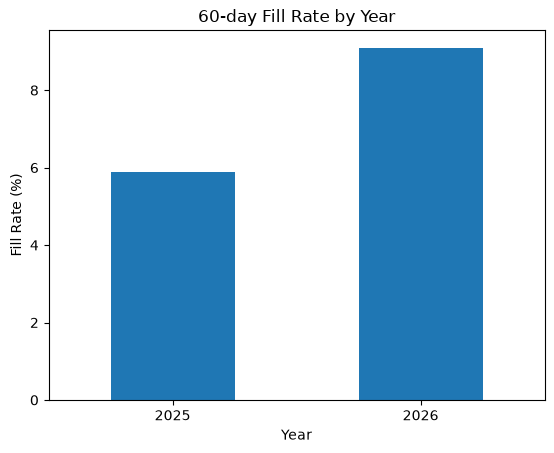

In [283]:
fill_rate_plot = (
    job_year_summary["fill_rate_60d"]
    * 100
)

fill_rate_plot.plot(
    kind="bar"
)

plt.title(
    "60-day Fill Rate by Year"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Fill Rate (%)"
)

plt.xticks(
    rotation=0
)

plt.show()

### 10.1 60日観察可能求人の確認
データ期間末付近に公開された求人は、求人公開後60日間を十分に観察できない。

そのため、年ごとに60日観察可能な求人件数と募集枠数を確認する。

In [284]:
job_df.groupby(
    [
        "open_year",
        "job_60d_observed_flag",
    ]
).agg(
    job_count=(
        "job_id",
        "count",
    ),
    total_slots=(
        "required_slots",
        "sum",
    ),
)

job_count  total_slots
open_year job_60d_observed_flag                        
2025      1                             10           17
2026      0                              3            5
          1                              7           11

## 11. 給与不足率の年次比較
候補者の希望時給に対して、求人提示時給がどの程度不足しているかを確認する。

`wage_shortfall_rate` は、
`max((希望時給 - 提示時給) ÷ 希望時給, 0)`
として算出する。

提示時給が希望時給以上の場合は0となる。

この指標を使用することで、提示時給が希望時給を上回る案件に影響されず、「給与条件が候補者希望に届いていない程度」を直接比較できる。

2026年に給与不足率が高くなっている場合、給与ミスマッチが拡大している可能性がある。

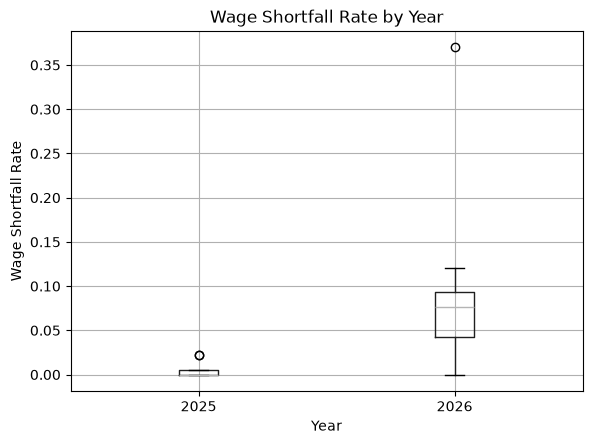

In [285]:
application_df.boxplot(
    column="wage_shortfall_rate",
    by="application_year"
)

plt.title(
    "Wage Shortfall Rate by Year"
)

plt.suptitle("")

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Wage Shortfall Rate"
)

plt.show()

### 11.1 給与不足が大きい案件の確認
給与不足率が高い応募案件について、希望時給、提示時給、応募経路を確認する。

給与不足が大きいにもかかわらず応募へ進んでいる案件が、self_entryとCA紹介のどちらで発生しているかも確認する。

In [286]:
application_df[
    [
        "application_id",
        "job_id",
        "candidate_id",
        "offered_hourly_wage",
        "desired_hourly_wage",
        "wage_shortfall_rate",
        "wage_requirement_met_flag",
        "application_source",
        "application_status",
    ]
].sort_values(
    "wage_shortfall_rate",
    ascending=False,
)

,application_id,job_id,candidate_id,offered_hourly_wage,desired_hourly_wage,wage_shortfall_rate,wage_requirement_met_flag,application_source,application_status
16,APP00017,JOB00020,CAN00002,1450,2300,0.370,0,self_entry,withdrawn
10,APP00011,JOB00012,CAN00008,1450,1650,0.121,0,ca_introduction,placed
12,APP00013,JOB00013,CAN00001,1450,1600,0.094,0,self_entry,withdrawn
11,APP00012,JOB00002,CAN00008,1500,1650,0.091,0,ca_introduction,rejected
15,APP00016,JOB00019,CAN00006,1550,1700,0.088,0,self_entry,rejected
13,APP00014,JOB00017,CAN00002,2150,2300,0.065,0,self_entry,rejected
8,APP00009,JOB00015,CAN00007,2300,2450,0.061,0,self_entry,recommended
17,APP00018,JOB00014,CAN00005,1350,1400,0.036,0,self_entry,recommended
5,APP00006,JOB00007,CAN00002,2250,2300,0.022,0,self_entry,withdrawn
0,APP00001,JOB00010,CAN00002,2250,2300,0.022,0,self_entry,placed


## 12. スキルミスマッチの年次比較
スキルミスマッチは、以下の2つに分けて確認する。

1. 求人と同じ職種の経験があるか
2. 同職種経験がある場合、候補者スキルレベルが求人要求スキルレベルを満たしているか

`same_occupation_experience_flag` は同職種経験の有無を表す。

`skill_gap` は、
`候補者スキルレベル - 求人要求スキルレベル`
として算出し、同職種経験がない場合はNULLとする。

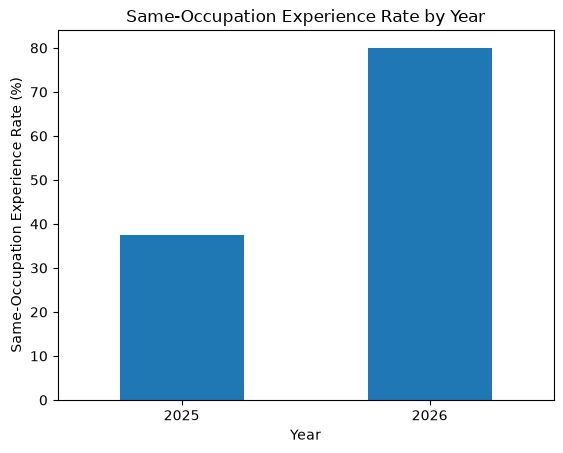

In [287]:
experience_rate_by_year = (
    application_df
    .groupby("application_year")[
        "same_occupation_experience_flag"
    ]
    .mean()
    * 100
)

experience_rate_by_year.plot(
    kind="bar"
)

plt.title(
    "Same-Occupation Experience Rate by Year"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Same-Occupation Experience Rate (%)"
)

plt.xticks(
    rotation=0
)

plt.show()

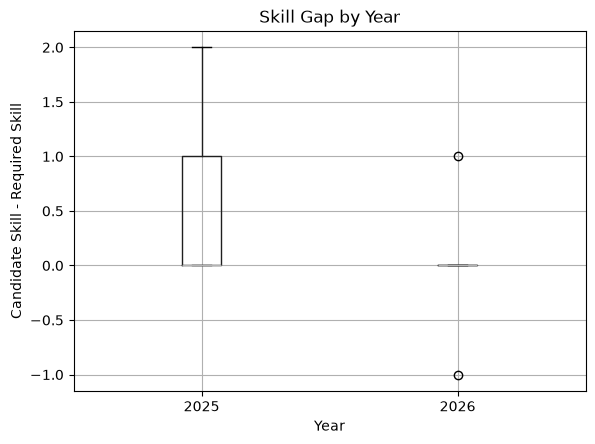

In [288]:
application_df.boxplot(
    column="skill_gap",
    by="application_year"
)

plt.title(
    "Skill Gap by Year"
)

plt.suptitle("")

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Candidate Skill - Required Skill"
)

plt.show()

### 12.1 同職種経験の有無を年次別に確認
`skill_gap` は、求人と同じ職種の経験がある応募案件についてのみ算出される。

同職種経験がない場合は `candidate_skill_level` および `skill_gap` がNULLとなるため、箱ひげ図だけでは全応募案件のスキルミスマッチを把握できない。

そこで、`same_occupation_experience_flag` を使用し、2025年・2026年それぞれについて、求人と同じ職種の経験を持つ応募案件と、同職種経験を持たない応募案件の件数を確認する。

この確認により、
- 同職種経験そのものがないミスマッチ
- 同職種経験はあるが要求スキルレベルとの差があるミスマッチ
を分けて確認できる。

In [289]:
pd.crosstab(
    application_df["application_year"],
    application_df["same_occupation_experience_flag"],
    margins=True,
)

same_occupation_experience_flag,0,1,All
application_year,,,
2025,5,3,8
2026,2,8,10
All,7,11,18


### 12.2 応募経路別の同職種経験有無の確認
`self_entry` と `ca_introduction` では、応募に至るまでのプロセスが異なる。

候補者自身による `self_entry` では、未経験職種への応募が一定数発生することを許容している。

一方、`ca_introduction` では、CAが候補者の職歴やスキルを確認したうえで求人を紹介するため、特に要求スキルレベルの高い求人では同職種経験をより重視する生成ロジックとしている。

そのため、応募経路別に `same_occupation_experience_flag` を確認し、
- self_entryでは同職種経験なしの応募が一定数存在するか
- ca_introductionでは同職種経験なしの応募が過度に多くなっていないか
を確認する。

なお、小規模テストデータでは件数が少ないため、経路間の割合差そのものを分析結果とは判断せず、生成ロジックが不自然な分布を作っていないかを確認する。

In [290]:
pd.crosstab(
    application_df["application_source"],
    application_df["same_occupation_experience_flag"],
    margins=True,
)

same_occupation_experience_flag,0,1,All
application_source,,,
ca_introduction,3,2,5
self_entry,4,9,13
All,7,11,18


### 12.3 給与不足とスキル適合度の組み合わせ確認
給与条件とスキル条件のミスマッチが同じ応募案件で重なっていないかを確認する。

`wage_shortfall_rate` が大きいほど、求人提示時給が候補者希望時給を下回っている割合が大きいことを示す。

あわせて、
- 同職種経験の有無
- 候補者スキルレベル
- 求人要求スキルレベル
- `skill_gap`
を確認する。

例えば、
- 給与不足は大きいがスキル条件は満たしている案件
- 給与条件は問題ないがスキル条件が不足している案件
- 給与不足とスキル不足の両方が存在する案件
では、応募後の選考結果に与える影響が異なる可能性がある。

この段階では因果関係を判断せず、複数のミスマッチが同時に発生している案件が存在するかを探索的に確認する。

In [291]:
application_df[
    [
        "application_id",
        "application_source",
        "offered_hourly_wage",
        "desired_hourly_wage",
        "wage_shortfall_rate",
        "required_skill_level",
        "same_occupation_experience_flag",
        "candidate_skill_level",
        "skill_gap",
    ]
].sort_values(
    "wage_shortfall_rate",
    ascending=False,
)

,application_id,application_source,offered_hourly_wage,desired_hourly_wage,wage_shortfall_rate,required_skill_level,same_occupation_experience_flag,candidate_skill_level,skill_gap
16,APP00017,self_entry,1450,2300,0.370,1,1,1.0,0.0
10,APP00011,ca_introduction,1450,1650,0.121,2,1,2.0,0.0
12,APP00013,self_entry,1450,1600,0.094,1,0,NaN,NaN
11,APP00012,ca_introduction,1500,1650,0.091,2,1,2.0,0.0
15,APP00016,self_entry,1550,1700,0.088,3,1,2.0,-1.0
13,APP00014,self_entry,2150,2300,0.065,3,1,3.0,0.0
8,APP00009,self_entry,2300,2450,0.061,3,1,4.0,1.0
17,APP00018,self_entry,1350,1400,0.036,1,1,1.0,0.0
5,APP00006,self_entry,2250,2300,0.022,3,1,3.0,0.0
0,APP00001,self_entry,2250,2300,0.022,3,1,3.0,0.0


## 13. 応募意思確認から推薦までの日数の年次比較
応募意思を確認してから企業推薦までに要した日数を比較する。

`intent_to_recommend_days` が長いほど、応募意思確認後の推薦プロセスに時間を要していることを示す。
`intent_to_recommend_days` は推薦日が存在する応募案件のみで算出されるため、箱ひげ図は実質的に推薦まで進んだ案件を対象としている。

2026年に分布が長期化している場合、選考プロセスの遅延が発生している可能性がある。

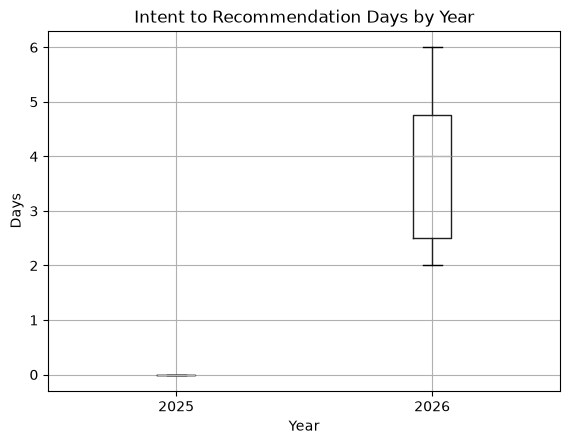

In [292]:
application_df.boxplot(
    column="intent_to_recommend_days",
    by="application_year"
)

plt.title(
    "Intent to Recommendation Days by Year"
)

plt.suptitle("")

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Days"
)

plt.show()

### 13.1 推薦までの日数が長い案件の確認
箱ひげ図では、2025年の推薦までの日数はほぼ0日である一方、2026年では2〜6日程度に分布しており、2026年の方が推薦までに時間を要している傾向が確認された。

この差が生成ロジック上の意図した遅延として発生しているか、また特定の案件だけが極端に長期化しているのではないかを確認するため、応募意思確認から推薦までの日数が長い順に案件を確認する。

あわせて、応募経路、推薦結果、辞退有無、最終的な就業決定有無を確認し、推薦までのリードタイムが後続工程にどのようにつながっているかを探索的に確認する。

なお、現在は小規模テストデータであるため、2025年と2026年の差そのものを最終的な分析結果とは判断せず、生成ロジックが想定した方向性で機能しているかを確認する。

In [293]:
application_df[
    [
        "application_id",
        "application_source",
        "intent_confirmed_date",
        "recommendation_date",
        "intent_to_recommend_days",
        "withdrawal_flag",
        "recommendation_result",
        "placed_flag",
    ]
].sort_values(
    "intent_to_recommend_days",
    ascending=False
)

,application_id,application_source,intent_confirmed_date,recommendation_date,intent_to_recommend_days,withdrawal_flag,recommendation_result,placed_flag
17,APP00018,self_entry,2026-09-24,2026-09-30,6.0,0,accepted,0
15,APP00016,self_entry,2026-08-06,2026-08-11,5.0,0,rejected,0
11,APP00012,ca_introduction,2026-05-30,2026-06-03,4.0,0,rejected,0
13,APP00014,self_entry,2026-06-30,2026-07-04,4.0,0,rejected,0
8,APP00009,self_entry,2026-05-15,2026-05-17,2.0,0,accepted,0
10,APP00011,ca_introduction,2026-05-30,2026-06-01,2.0,0,accepted,1
0,APP00001,self_entry,2025-05-12,2025-05-12,0.0,0,accepted,1
1,APP00002,ca_introduction,2025-07-09,2025-07-09,0.0,0,rejected,0
2,APP00003,self_entry,2025-07-11,NaN,NaN,0,NaN,0
3,APP00004,self_entry,2025-07-19,NaN,NaN,0,NaN,0


## 14. 就業決定率の年次比較
応募案件のうち、最終的に就業決定へ至った割合を2025年と2026年で比較する。

就業決定率は、給与条件、スキル適合度、選考リードタイムなど複数要因の影響を受けた最終結果の一つとして確認する。

なお、データ期間末付近の未成熟案件の影響を避けるため、応募意思確認後30日間を観察できる案件のみを対象とする。

現在は小規模テストデータであるため、年次差そのものを分析結果とは判断せず、集計ロジックと生成データの方向性を探索的に確認する。

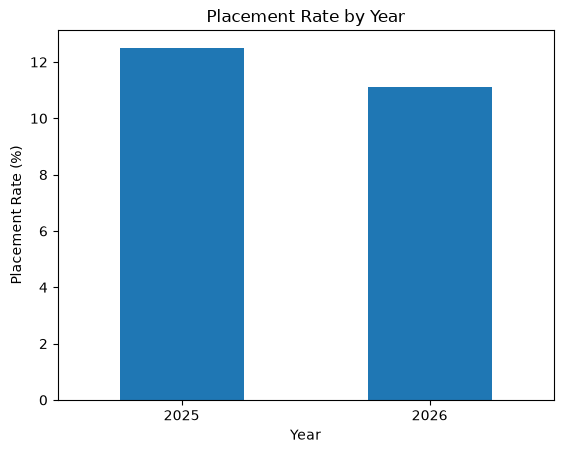

In [294]:
placement_rate_plot = (
    application_year_summary[
        "placement_rate"
    ]
    * 100
)

placement_rate_plot.plot(
    kind="bar"
)

plt.title(
    "Placement Rate by Year"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Placement Rate (%)"
)

plt.xticks(
    rotation=0
)

plt.show()

### 14.1 就業決定率の分子・分母の確認
年次比較で使用した就業決定率について、年ごとの観察可能応募案件数、就業決定件数、就業決定率を確認する。

就業決定率は、応募意思確認後30日間を観察できる案件のみを分母とする。

これにより、データ期間末付近の未成熟案件を未決定案件として扱うことを避ける。

In [295]:
application_30d_observed_df.groupby(
    "application_year"
).agg(
    observed_application_count=(
        "application_id",
        "count",
    ),
    placement_count=(
        "placed_flag",
        "sum",
    ),
    placement_rate=(
        "placed_flag",
        "mean",
    ),
)

,observed_application_count,placement_count,placement_rate
application_year,,,
2025,8,1,0.125000
2026,9,1,0.111111


### 14.2 月別の応募件数と観察可能件数の確認
データ期間末付近の応募案件では、就業決定までの十分な観察期間を確保できていない可能性がある。

そのため、応募月ごとに全応募案件数と30日観察可能案件数を比較し、未成熟案件がどの月に含まれているかを確認する。

In [296]:
application_df.groupby(
    "application_month"
).agg(
    application_count=(
        "application_id",
        "count",
    ),
    observed_application_count=(
        "application_30d_observed_flag",
        "sum",
    ),
    placement_count=(
        "placed_flag",
        "sum",
    ),
)

,application_count,observed_application_count,placement_count
application_month,,,
2025-05,1,1,1
2025-07,3,3,0
2025-08,1,1,0
2025-09,3,3,0
2026-05,4,4,1
2026-06,2,2,0
2026-07,1,1,0
2026-08,2,2,0
2026-09,1,0,0


### 14.2.1 観察可能案件に限定した月別就業決定率
30日間観察可能な応募案件のみを対象として、月別の応募案件数、就業決定件数、就業決定率を確認する。

小規模データでは月ごとの件数が少ないため、この値自体を月次傾向とは判断せず、観察期間の取り扱いが適切であることを確認する。

In [297]:
application_30d_observed_df.groupby(
    "application_month"
).agg(
    application_count=(
        "application_id",
        "count",
    ),
    placement_count=(
        "placed_flag",
        "sum",
    ),
    placement_rate=(
        "placed_flag",
        "mean",
    ),
)

,application_count,placement_count,placement_rate
application_month,,,
2025-05,1,1,1.00
2025-07,3,0,0.00
2025-08,1,0,0.00
2025-09,3,0,0.00
2026-05,4,1,0.25
2026-06,2,0,0.00
2026-07,1,0,0.00
2026-08,2,0,0.00


### 14.3 応募案件ステータスの確認
データ期間末時点における応募案件のステータス分布を確認する。

今回の生成ロジックでは、CA判断による推薦対象外案件を `screened_out`、データ期間末時点で処理中の案件を `confirmed` として区別している。

そのため、推薦対象外案件と処理中案件が混在せず、それぞれ意図した意味で生成されているかを確認する。

In [298]:
application_df[
    "application_status"
].value_counts(
    dropna=False
)

application_status
screened_out    6
rejected        4
withdrawn       4
placed          2
recommended     2
Name: count, dtype: int64

## 15. 小規模再生成後のEDA所感

### 15.1 データ品質
生成ロジック修正後の小規模データについて、SQLite分析マートを再作成し、EDAを再実行した。

`mart_job_analysis` と `mart_application_analysis` は正常に作成され、求人・応募案件ともに想定した粒度で読み込むことができた。

今回追加した以下の項目も正常に利用できることを確認した。
- `job_60d_observed_flag`
- `application_30d_observed_flag`
- `same_occupation_experience_flag`
- `wage_shortfall_rate`
- `screened_out_flag`
- `confirmed_flag`

60日間観察できない求人では `fill_rate_60d` がNULLとなり、同職種経験がない応募案件では `skill_gap` がNULLとなるなど、分析上意味のある欠損とデータ不良を区別できる状態となった。

また、データ期間末付近の求人・応募案件について、観察期間が不足している案件をフラグで区別できるようになった。

### 15.2 60日以内募集枠充足率
60日以内募集枠充足率は、求人公開後60日間をデータ期間内で観察できる求人のみを対象として算出した。

これは、データ期間末付近に公開された求人を、十分な観察期間がないにもかかわらず未充足求人として分母へ含めることを避けるためである。

なお、求人が60日以内にクローズした場合でも、求人公開後60日間の結果をデータ上確認できる求人であれば分析対象に含める。

小規模データにおける60日以内募集枠充足率は、
- 2025年：約5.9%
- 2026年：約9.1%
となった。

今回の小規模データでは、想定している「2026年に充足率が低下する」という方向性は確認されなかった。
ただし、2025年は17募集枠、2026年は11観察可能募集枠に対し、それぞれ60日以内就業決定が1件である。

そのため、1件の就業決定が充足率へ与える影響が大きく、この結果のみから仮説の方向性を評価することは適切ではない。
今回の小規模データでは、60日観察可能求人の抽出と充足率の集計ロジックが正しく機能していることを確認できれば十分と判断する。

### 15.3 応募経路と応募案件化
応募案件 `applications` は、以下の2つの経路から生成される。
- `self_entry`
- `ca_introduction`
ただし、求人エントリー `job_entries` がすべて応募案件へ変換されるわけではない。
`self_entry` では、候補者が求人へエントリーした後、同職種経験やスキル適合度などに応じて応募案件化する確率を変化させている。

一方、`ca_introduction` は求人エントリーを経由せず、CAによる求人紹介から応募案件へ進む。

そのため、
`entry_count < application_count`
となる場合も、
`entry_count > application_count`
となる場合もあり得る。

今回の小規模データにおいて、求人エントリー数と応募案件数が一致しないことは、生成ロジック上の異常ではないことを確認した。

### 15.4 給与ミスマッチ
給与ミスマッチについては、提示時給が希望時給を下回る程度を直接表す `wage_shortfall_rate` を主に確認した。

平均給与不足率は、
- 2025年：約0.6%
- 2026年：約9.3%
となった。

また、希望時給以上の提示時給となっている応募案件の割合は、
- 2025年：75%
- 2026年：20%
であった。

小規模データではあるものの、2026年に給与条件のミスマッチが拡大する方向性が確認された。
給与ミスマッチについては、生成ロジックが想定した方向に機能していると考えられる。

### 15.5 スキルミスマッチ
スキルミスマッチは、以下の2つに分けて確認した。
1. 求人と同じ職種の経験があるか
2. 同職種経験がある場合、候補者スキルレベルが求人要求スキルレベルを満たしているか

同職種経験を持つ応募案件の割合は、
- 2025年：37.5%
- 2026年：80.0%
となった。

今回の小規模データでは、2026年の方が同職種経験を持つ応募案件の割合が高く、想定しているスキルミスマッチ拡大の方向性とは一致しなかった。

一方、応募案件数は2025年8件、2026年10件と少なく、CA紹介時のスクリーニング強化による影響も受ける。

そのため、現時点では生成異常とは判断しない。

また、`skill_gap` は同職種経験がある応募案件のみで算出するため、箱ひげ図だけでなく `same_occupation_experience_flag` と組み合わせて評価する必要がある。

### 15.6 選考リードタイム
応募意思確認から推薦までの平均日数は、
- 2025年：0日
- 2026年：約3.8日
となった。

箱ひげ図でも、2025年はほぼ0日である一方、2026年では2〜6日程度に分布しており、2026年の方が推薦までに時間を要している傾向が確認された。

今回の小規模データでは、選考リードタイムが2026年に長期化する方向性が確認された。

ただし、件数が少ないため、差そのものを最終的な分析結果とは判断せず、生成ロジックが想定した方向に機能していることを確認する。

### 15.7 応募案件ステータス
生成ロジック修正により、CA判断による推薦対象外案件を `screened_out`、データ期間末時点で処理中の案件を `confirmed` として区別できるようになった。

これにより、修正前に発生していた「推薦対象外案件と処理中案件が `confirmed` に混在する」という問題は改善された。

今後の分析では、`screened_out` を推薦前の選考結果の一つとして扱い、`confirmed` はデータ期間末時点で結果を観察できていない可能性がある処理中案件として区別する。

### 15.8 辞退率の取り扱い
現在の `withdrawal_flag` は、`applications.withdrawal_date` が存在する応募案件を表している。

現在の生成ロジックでは、この辞退は主として応募意思確認後から企業推薦前までの候補者辞退として生成されている。

そのため、現在の `withdrawal_rate` は、応募意思確認後から就業決定までの全選考期間における総辞退率ではなく、実質的には推薦前辞退率に近い指標である。

実際の業務では、応募意思確認直後の辞退だけでなく、推薦後や職場見学後にも候補者辞退が発生する。

分析用データ生成では、辞退の発生段階をより明確にするため、以下の区分を追加する予定である。

- `pre_recommendation_withdrawal`
- `post_recommendation_withdrawal`
- `post_visit_withdrawal`

これにより、選考プロセスのどの段階で候補者離脱が発生しているかを分析できるようにする。

### 15.9 就業決定率
就業決定率は、応募意思確認後30日間を観察できる応募案件のみを対象として算出した。
データ期間末付近の応募案件は、推薦、職場見学、就業決定まで進むための十分な時間がない可能性がある。

そのような案件を `placed_flag = 0` として分母へ含めると、就業決定率を実態より低く見せる可能性があるため、`application_30d_observed_flag = 1` の案件に限定した。

30日観察可能案件に限定した就業決定率は、
- 2025年：12.5%
- 2026年：約11.1%
となった。

分子を見ると、両年とも就業決定件数は1件であり、
- 2025年：8件中1件
- 2026年：9件中1件
である。

そのため、今回の小規模データでは年次差そのものを評価せず、30日観察可能案件のみを分母とする集計ロジックが正しく機能していることを確認する。

なお、30日という観察期間は、現在の生成プロセスにおける推薦、職場見学、就業決定までの日数を考慮して設定した分析上の基準である。

### 15.10 小規模再テストの結論
今回の再生成により、初回EDAで確認された以下の構造上の問題について修正を反映した。
- 候補者登録時期の偏り
- 求人公開期間
- 求人終了後の新規エントリー・求人紹介
- CA紹介時のスキルスクリーニング
- self_entry後の応募案件化におけるスキルスクリーニング
- 推薦対象外案件と処理中案件の区別
- 同職種経験有無の明示
- 給与不足率の追加
- 期間末の未成熟求人・応募案件の区別

小規模再テストでは、
- 給与ミスマッチは2026年に悪化する方向
- 選考リードタイムは2026年に長期化する方向
- スキルミスマッチは想定方向と一致しない
- 60日以内募集枠充足率は想定方向と一致しない
- 就業決定率には明確な年次差は確認されない
という結果となった。

ただし、今回の目的は仮説の最終評価ではなく、
`Python生成スクリプト → CSV → SQLite → SQL分析マート → Python EDA`
という一連の分析基盤が正しく接続されていること、および生成ロジックに重大な不整合がないことを確認することである。

その目的については、小規模テストで確認できたと判断する。

### 15.11 次のステップ
今回の小規模テストにより、生成処理、SQLite、SQL分析マート、EDAまでの一連の処理が正常に動作することを確認できた。

次は単純にデータ件数を増やすための中規模テストではなく、統計分析に使用することを前提とした分析用合成データを生成する。

分析用データでは、今回の小規模テストで確認した生成ロジックをベースとしつつ、以下を追加で調整する。

- 候補者数、求人件数、応募案件数を統計分析に十分な規模へ拡張する
- 2025年と2026年で求人需要と候補者供給のバランスを意図した範囲で変化させる
- 給与ミスマッチ、スキルミスマッチ、求人構成、選考リードタイムに一定の効果を持たせる
- 仮説と完全一致する決定論的なデータにはせず、個体差やランダム性を残す
- 辞退を `pre_recommendation_withdrawal`、`post_recommendation_withdrawal`、`post_visit_withdrawal` に分ける

分析用データ生成後は、EDAによる分布確認に加えて、Pythonを用いて以下の統計分析へ進む。

- 記述統計
- 信頼区間
- 年次差の検定
- 効果量
- 相関分析
- ロジスティック回帰などの多変量分析

最終的には、「2026年に求人充足率が低下したとした場合、どの要因がどの程度関連しているか」を、単純な年次比較だけでなく複数の統計的手法を用いて検証する。